<a href="https://colab.research.google.com/github/maenglion/dv-analysis/blob/main/crawler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install beautifulsoup4 pandas

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

# 1. 설정 및 타깃 정보
url = "https://kdata.or.kr/datavoucher/ep/ptSpplEnprSearchList.do"
target_keywords = ["가공", "전처리", "품질", "코딩", "시각화", "정보추출또는조합", "태깅또는라벨링", "분석"]

raw_data = []
# 723개 기업 / 페이지당 5개 = 총 145개 페이지 자동 루프
total_pages = 145

print("================ 데이터 수집 시작 ================")
for page in range(1, total_pages + 1):
    print(f"현재 {page} / {total_pages} 페이지 스캔 중...")

    # 페이징 파라미터 전송
    params = {'pageIndex': page}

    try:
        # 사이트가 GET/POST 중 어떤 방식이든 대응하도록 우선 기본 세팅
        response = requests.get(url, params=params, timeout=10)
        soup = BeautifulSoup(response.text, 'html.parser')

        # 확인된 확실한 데이터 레이어 '#main li' 선택
        li_elements = soup.select('#main li')

        for li in li_elements:
            txt = li.get_text().replace('\n', ' ').strip()
            clean_text = " ".join(txt.split())

            # 의미 없는 데이터나 중복 제거 후 배열에 누적
            if len(clean_text) > 5 and clean_text not in raw_data:
                raw_data.append(clean_text)

    except Exception as e:
        print(f">> {page} 페이지 통신 중 오류 발생: {e}")

    time.sleep(0.3) # 서버 부하 방지를 위한 미세 딜레이

print(f"\n================ 수집 완료 (총 {len(raw_data)}개의 데이터 레이어 확보) ================")
print("================ 매트릭스 정제 및 키워드 매칭 시작 ================")

# 2. 수집된 텍스트 기반 구조화 정제 로직
processed_companies = []
current_company = None

for item in raw_data:
    if "조회수" in item or "등록일:" in item:
        continue
    if item.startswith("관심 클릭수") and len(item.split()) == 3:
        continue

    # 기업명 추출 (독립 단문 명칭을 기업명 스냅샷으로 확보)
    if not item.startswith("관심 클릭수") and not any(kw in item for kw in ["개요", "핵심역량", "당사는", "선정", "출범"]):
        if len(item) < 30:
            current_company = {
                "company_name": item,
                "keywords_line": "",
                "description": ""
            }
            processed_companies.append(current_company)
            continue

    # 획득한 기업명 아래에 매핑되는 데이터 수집
    if current_company:
        if item.startswith("관심 클릭수"):
            current_company["keywords_line"] = item
        else:
            current_company["description"] = item

# 3. 키워드 일치도 다차원 매트릭스 연산
final_table = []
for co in processed_companies:
    full_text = co["keywords_line"] + " " + co["description"]

    match_status = {}
    match_count = 0
    for kw in target_keywords:
        if kw in full_text:
            match_status[kw] = "O"
            match_count += 1
        else:
            match_status[kw] = "X"

    row = {
        "기업명": co["company_name"],
        "제공 서비스 분야": co["keywords_line"].replace("관심 클릭수 ", "").split(" 가공")[0] if co["keywords_line"] else "",
        "일치 키워드 수": match_count,
        "일치도(%)": round((match_count / len(target_keywords)) * 100, 1)
    }
    row.update(match_status)
    final_table.append(row)

# 4. 판다스 데이터프레임 변환 후 엑셀 호환 CSV 저장
df = pd.DataFrame(final_table)
df = df.drop_duplicates(subset=['기업명'], keep='first') # 중복 기업 청소
df = df.sort_values(by="일치 키워드 수", ascending=False) # 고일치도 기업 순 정렬

df.to_csv("datavoucher_total_analysis.csv", index=False, encoding="utf-8-sig")

print("\n================ 최종 가공 완료 ================")
print(f"가공 성공 기업 수: {len(df)}개")
print("결과가 'datavoucher_total_analysis.csv' 파일로 저장되었습니다. 왼쪽 파일 메뉴에서 다운로드하세요.")

================ 데이터 수집 시작 ================
현재 1 / 145 페이지 스캔 중...
현재 2 / 145 페이지 스캔 중...
현재 3 / 145 페이지 스캔 중...
현재 4 / 145 페이지 스캔 중...
현재 5 / 145 페이지 스캔 중...
현재 6 / 145 페이지 스캔 중...
현재 7 / 145 페이지 스캔 중...
현재 8 / 145 페이지 스캔 중...
현재 9 / 145 페이지 스캔 중...
현재 10 / 145 페이지 스캔 중...
현재 11 / 145 페이지 스캔 중...
현재 12 / 145 페이지 스캔 중...
현재 13 / 145 페이지 스캔 중...
현재 14 / 145 페이지 스캔 중...
현재 15 / 145 페이지 스캔 중...
현재 16 / 145 페이지 스캔 중...
현재 17 / 145 페이지 스캔 중...
현재 18 / 145 페이지 스캔 중...
현재 19 / 145 페이지 스캔 중...
현재 20 / 145 페이지 스캔 중...
현재 21 / 145 페이지 스캔 중...
현재 22 / 145 페이지 스캔 중...
현재 23 / 145 페이지 스캔 중...
현재 24 / 145 페이지 스캔 중...
현재 25 / 145 페이지 스캔 중...
현재 26 / 145 페이지 스캔 중...
현재 27 / 145 페이지 스캔 중...
현재 28 / 145 페이지 스캔 중...
현재 29 / 145 페이지 스캔 중...
현재 30 / 145 페이지 스캔 중...
현재 31 / 145 페이지 스캔 중...
현재 32 / 145 페이지 스캔 중...
현재 33 / 145 페이지 스캔 중...
현재 34 / 145 페이지 스캔 중...
현재 35 / 145 페이지 스캔 중...
현재 36 / 145 페이지 스캔 중...
현재 37 / 145 페이지 스캔 중...
현재 38 / 145 페이지 스캔 중...
현재 39 / 145 페이지 스캔 중...
현재 40 / 145 페이지 스캔 중...
현재 41

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

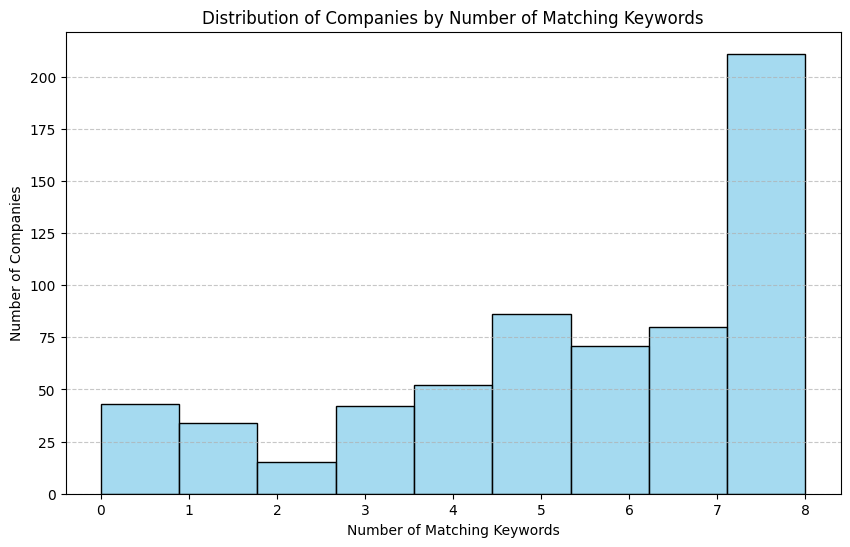

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['일치 키워드 수'], bins=len(df['일치 키워드 수'].unique()), kde=False, color='skyblue', edgecolor='black')
plt.title('Distribution of Companies by Number of Matching Keywords')
plt.xlabel('Number of Matching Keywords')
plt.ylabel('Number of Companies')
plt.xticks(sorted(df['일치 키워드 수'].unique()))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_6292/1619998913.py:24: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/1619998913.py:24: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/1619998913.py:24: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/1619998913.py:24: UserWarning: Glyph 49437 (\N{HANGUL SYLLABLE SEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/1619998913.py:24: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/1619998913.py:24: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/1619998913.py:24: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_

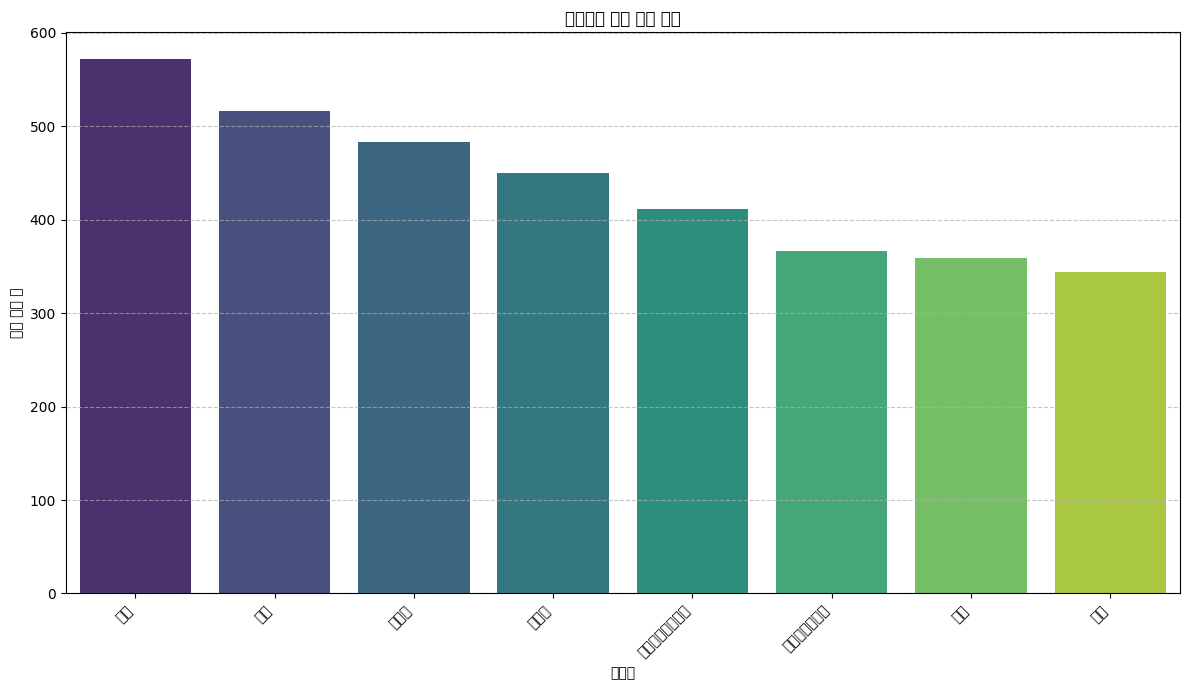

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported as it's used for DataFrame

# Configure font for Korean characters
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # To prevent breaking of minus signs

# Prepare data for keyword frequency
keyword_counts = {}
for kw in target_keywords:
    keyword_counts[kw] = df[kw].value_counts().get('O', 0) # Count 'O' for each keyword

keyword_freq_df = pd.DataFrame(list(keyword_counts.items()), columns=['Keyword', 'Frequency'])
keyword_freq_df = keyword_freq_df.sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Keyword', y='Frequency', data=keyword_freq_df, palette='viridis', hue='Keyword', legend=False)
plt.title('키워드별 기업 참여 빈도')
plt.xlabel('키워드')
plt.ylabel('참여 기업 수')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6292/2380848623.py:33: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/2380848623.py:33: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/2380848623.py:33: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/2380848623.py:33: UserWarning: Glyph 49437 (\N{HANGUL SYLLABLE SEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/2380848623.py:33: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/2380848623.py:33: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6292/2380848623.py:33: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_

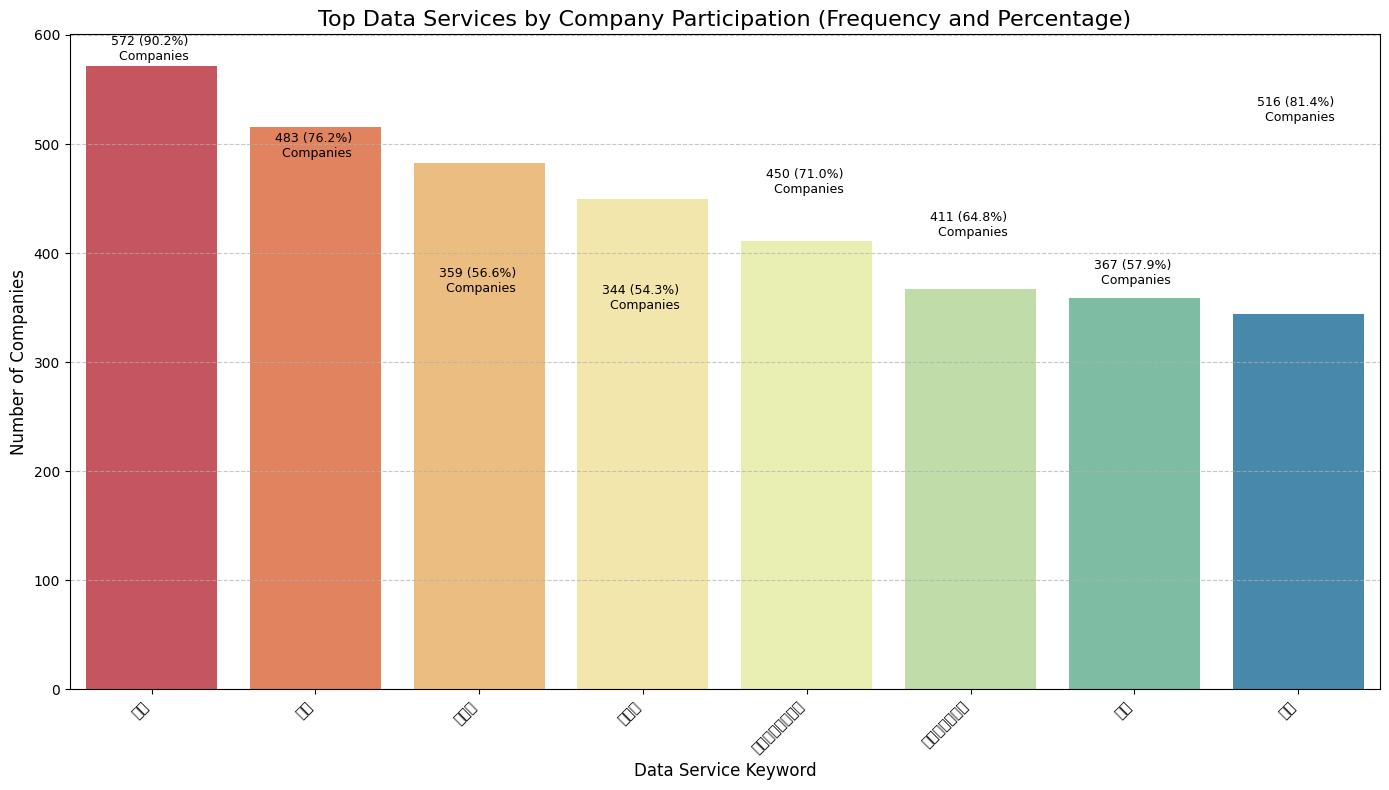

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configure font for Korean characters using Noto Sans KR
# This font is often pre-installed or easily available and supports Korean glyphs.
plt.rcParams['font.family'] = 'Noto Sans KR'
plt.rcParams['axes.unicode_minus'] = False # To prevent breaking of minus signs

# Get the top 12 keywords (or all if less than 12)
# Use .copy() to avoid SettingWithCopyWarning
top_keywords_df = keyword_freq_df.head(12).copy()

# Calculate total number of unique companies from the 'df' DataFrame
total_companies = len(df)

# Calculate percentage
top_keywords_df['Percentage'] = (top_keywords_df['Frequency'] / total_companies) * 100

plt.figure(figsize=(14, 8))
sns.barplot(x='Keyword', y='Frequency', data=top_keywords_df, palette='Spectral', hue='Keyword', legend=False)

# Add labels with frequency and percentage
for index, row in top_keywords_df.iterrows():
    plt.text(index, row['Frequency'] + 5, f"{row['Frequency']} ({row['Percentage']:.1f}%) \n Companies", color='black', ha='center', fontsize=9)

plt.title('Top Data Services by Company Participation (Frequency and Percentage)', fontsize=16)
plt.xlabel('Data Service Keyword', fontsize=12)
plt.ylabel('Number of Companies', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
# Install Noto CJK fonts for comprehensive East Asian language support
# This package often includes Noto Sans KR.
!sudo apt-get update -qq
!sudo apt-get install -y fonts-noto-cjk-extra

# Clear font cache
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

print("Noto CJK fonts installed and font caches cleared. Please RESTART the runtime (Runtime -> Restart runtime...) and then re-run the plotting cell (ac844834) to apply changes.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-noto-cjk
The following NEW packages will be installed:
  fonts-noto-cjk fonts-noto-cjk-extra
0 upgraded, 2 newly installed, 0 to remove and 29 not upgraded.
Need to get 206 MB of archives.
After this operation, 312 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk-extra all 1:20220127+repack1-1 [145 MB]
Fetched 206 MB in 3s (75.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. 

In [6]:
# Install Korean font for matplotlib
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
print("Korean font installed and font cache cleared. Please re-run the plotting cell (d9c1a74e) above.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (93.4 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct